# 02 - Modeling: Explainability

Explainability pass for the saved fraud model.

This notebook loads the saved artifact from `train.py`, recreates the validation split, and runs SHAP on a sample of that validation set.

Goal here is just to answer two questions:
- which features matter most overall
- what pushed a few individual transactions up or down

This is using the already-saved model artifact. No retraining in this notebook.

## Imports

In [7]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.data.load_data import load_raw_data
from src.data.preprocess import train_val_test_split

Project root: /Users/bavanakolasani/Desktop/real-time-fraud-decision-engine


## Load saved artifact

Same artifact `train.py` wrote out: preprocessing pipeline, trained model, and feature column list together.

In [16]:
ARTIFACT_PATH = "../artifacts/models/model_v1.pkl"

artifact = joblib.load(ARTIFACT_PATH)
pipeline = artifact["pipeline"]
model = artifact["model"]
feature_columns = artifact["feature_columns"]

print(f"Loaded model: {artifact.get('model_name', type(model).__name__)}")
print(f"Feature count: {len(feature_columns)}")

Loaded model: XGBoost
Feature count: 30


## Recreate validation split

Using the same split logic as training so this stays aligned with the held-out validation set used for threshold selection and analysis.

In [21]:
TARGET_COL = "Class"

DATA_PATH = PROJECT_ROOT / "data" / "creditcard.csv"
df = load_raw_data(path=str(DATA_PATH))

X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(df, target_col=TARGET_COL)

print(f"Validation rows: {X_val.shape[0]}")

Validation rows: 28481


## Take SHAP sample

No need to run SHAP on the full validation set here. A few hundred rows is enough to get the overall pattern, and keeping the sample fixed makes reruns easier to compare.

In [37]:
SAMPLE_SIZE = 300

X_val_sample = X_val.sample(n=min(SAMPLE_SIZE, len(X_val)), random_state=42)

# same preprocessing path used in training/inference
X_val_sample_t = pipeline.transform(X_val_sample)

print(f"SHAP sample rows: {X_val_sample_t.shape[0]}")
print(f"Transformed feature count: {X_val_sample_t.shape[1]}")

SHAP sample rows: 300
Transformed feature count: 30


## Global importance

Using `TreeExplainer` here since the saved model is XGBoost and this is the cheap path for tree models.

In [38]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_sample_t)

shap_values.shape

(300, 30)

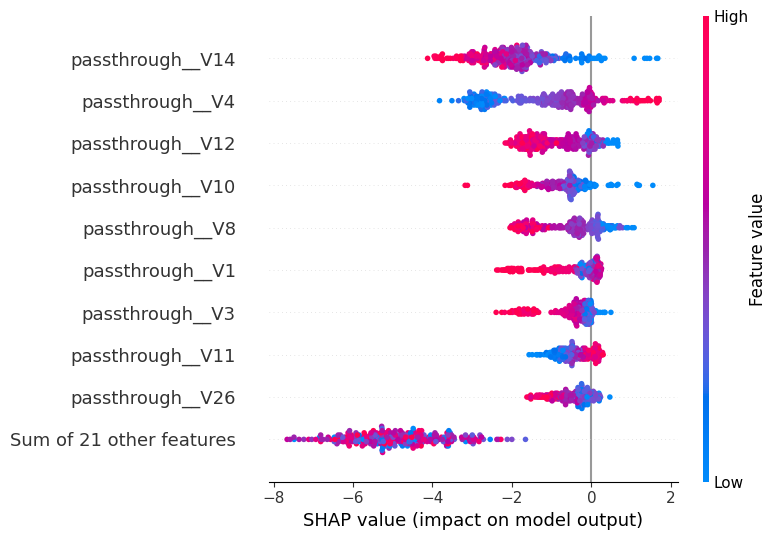

In [39]:
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.savefig("../artifacts/metrics/shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Local explanations

For a quick pass, using two contrasting examples from the sample: one very high risk score and one very low risk score.

In [43]:
risk_scores = model.predict_proba(X_val_sample_t)[:, 1]

idx_high = int(np.argmax(risk_scores))
idx_low = int(np.argmin(risk_scores))

print(f"High-score example: row {idx_high}, score={risk_scores[idx_high]:.4f}")
print(f"Low-score example: row {idx_low}, score={risk_scores[idx_low]:.4f}")

High-score example: row 275, score=0.1162
Low-score example: row 12, score=0.0000


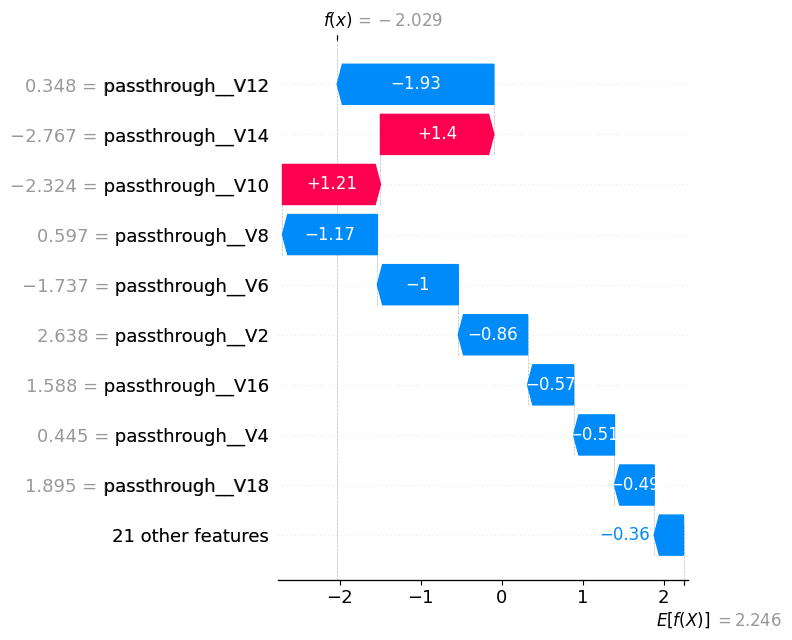

In [44]:
shap.plots.waterfall(shap_values[idx_high], show=False)
plt.tight_layout()
plt.savefig("../artifacts/metrics/shap_local_example_1.png", dpi=150, bbox_inches="tight")
plt.show()

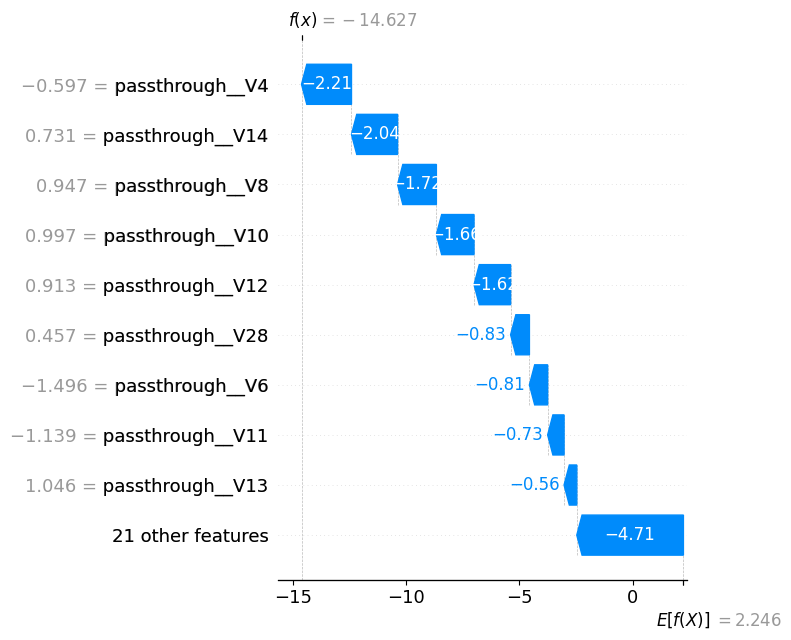

In [45]:
shap.plots.waterfall(shap_values[idx_low], show=False)
plt.tight_layout()
plt.savefig("../artifacts/metrics/shap_local_example_2.png", dpi=150, bbox_inches="tight")
plt.show()